# <h3 align="center">__Module 10 Activity__</h3>
# <h3 align="center">__Unnas Hussain__</h3>

# Module Activity: Exploring and Applying Unsupervised Learning Techniques

## Objectives:
1. Practice implementing basic unsupervised learning algorithms using Python.
2. Visualize and interpret results from clustering, dimensionality reduction, and anomaly detection.
3. Understand the role of distance metrics, eigenvalues, and thresholds in algorithm performance.

---

## Instructions:

### Step 1: Data Exploration
- Work with the iris dataset loaded using Python's `scikit-learn`.
- Explore the dataset by plotting the data points to observe natural groupings and potential outliers.

#### Code Snippet:


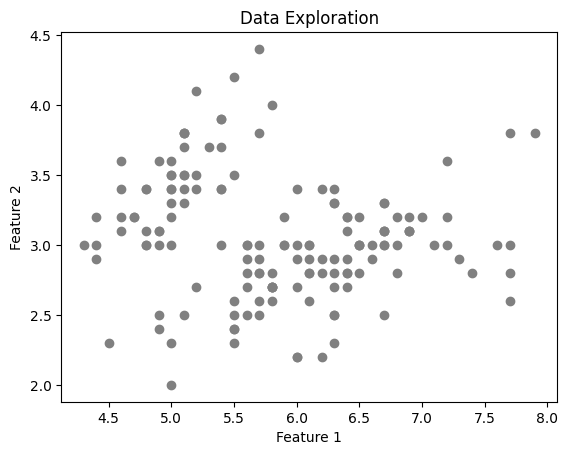

In [1]:
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt

data = load_iris()
X = data.data[:, :2]  # Use the first two features
plt.scatter(X[:, 0], X[:, 1], c='gray')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Data Exploration')
plt.show()

> From visually looking at the data, there seems to be at least 2 or 3 natural groupings visually. Outliers may be present at the extreme corners of the plot (8.0, 4.5) and (4.5, 2.0).

## Step 2: Clustering with K-Means
- Implement K-Means clustering using `scikit-learn`, choosing \( k=3 \).
- Visualize the results with cluster centroids and assigned labels.
- Discuss how initialization affects the results by trying multiple random seeds.

### Code:

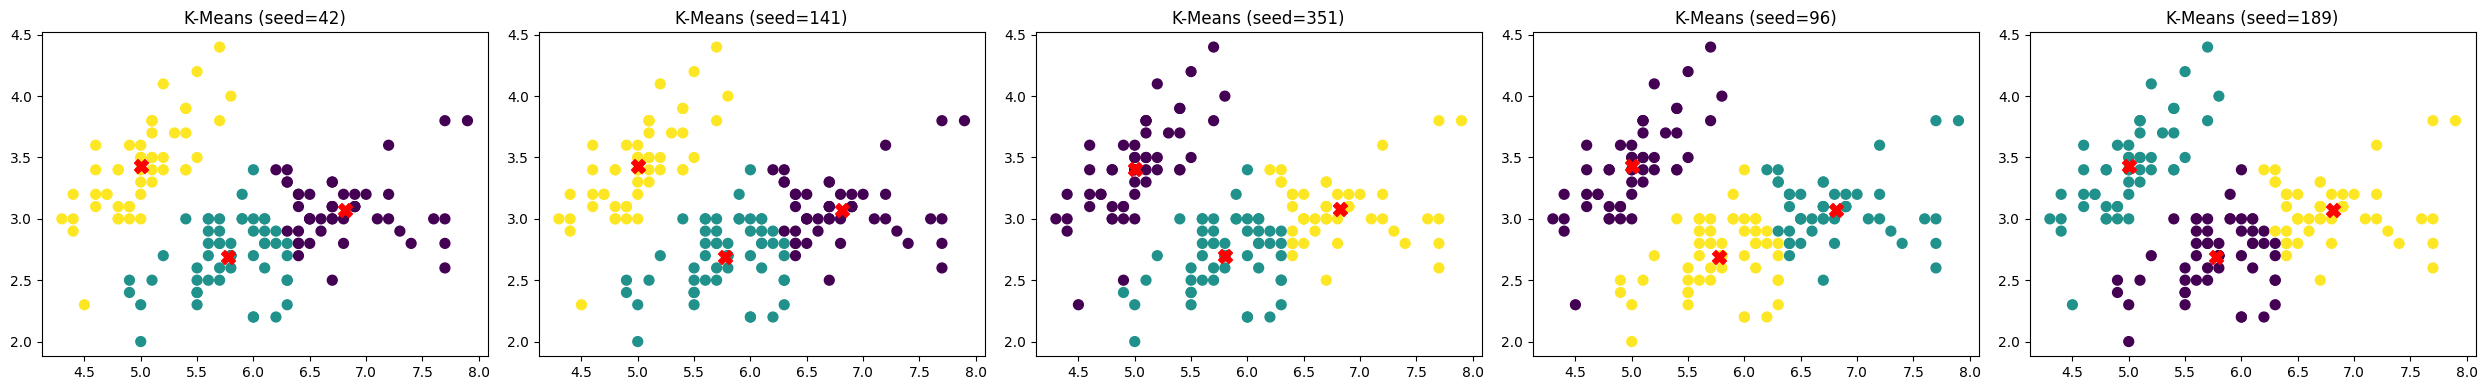

In [2]:
from sklearn.cluster import KMeans
import random

attempts = 5
initial_seed = 42

fig, axes = plt.subplots(1, attempts, figsize=(5 * attempts, 4))

for i in range(attempts):
    kmeans = KMeans(n_clusters=3, random_state=initial_seed)
    kmeans.fit(X)
    labels = kmeans.labels_
    centroids = kmeans.cluster_centers_

    axes[i].scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=50)
    axes[i].scatter(centroids[:, 0], centroids[:, 1], c='red', marker='X', s=100)
    axes[i].set_title(f'K-Means (seed={initial_seed})')
    initial_seed = int(random.random() * 500)

plt.tight_layout()
plt.show()

> Conceptually, initalization is very important for K-means, since its an iterative algorithm vunerable to settling in local minima. Pratically for this dataset, it seems like the centroids and boundaries are at least stable, with only two points near `(5.0, 2.5)` and `(6.5, 3.0)` swapping between two clusters

## Step 3: Dimensionality Reduction with PCA (20 Minutes)
- Perform Principal Component Analysis (PCA) to reduce the dataset to 2D.
- Visualize the transformed dataset and discuss how PCA retains variance.

### Code :

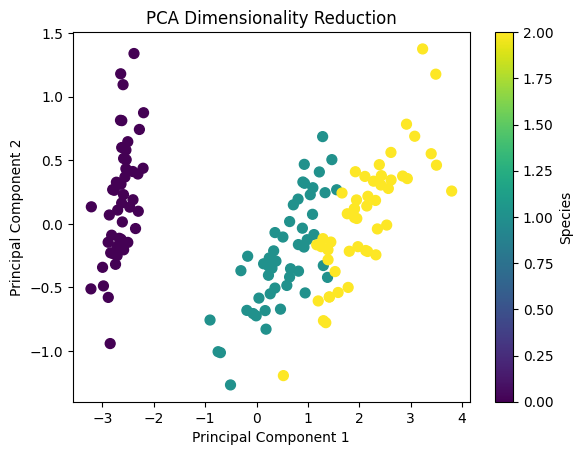

Explained variance ratio: [0.92461872 0.05306648]
Total variance explained: 0.9777


In [3]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(data.data)

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=data.target, cmap='viridis', s=50)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA Dimensionality Reduction')
plt.colorbar(label='Species')
plt.show()

print(f"Explained variance ratio: {pca.explained_variance_ratio_}")
print(f"Total variance explained: {sum(pca.explained_variance_ratio_):.4f}")

> PCA reduces the original 4-dimensional Iris dataset to 2 principal components while retaining high total variance. The first principal component captures the largest direction of variance in the data, while the second captures the next orthogonal direction. In the visualization (not actual unsupervized learning) we can use the species labels to see clear separation between species, demonstrating that PCA effectively preserves the key patterns and structure in the data. The explained variance ratio shows how much information each component contributes—PC1 typically explains ~73% and PC2 ~23% of variance.

## Step 4: Anomaly Detection with DBSCAN (20 Minutes)
- Apply DBSCAN to detect anomalies in the dataset.
- Tune the `eps` and `min_samples` parameters and visualize outliers.
- Discuss how varying these parameters impacts results.

### Code:

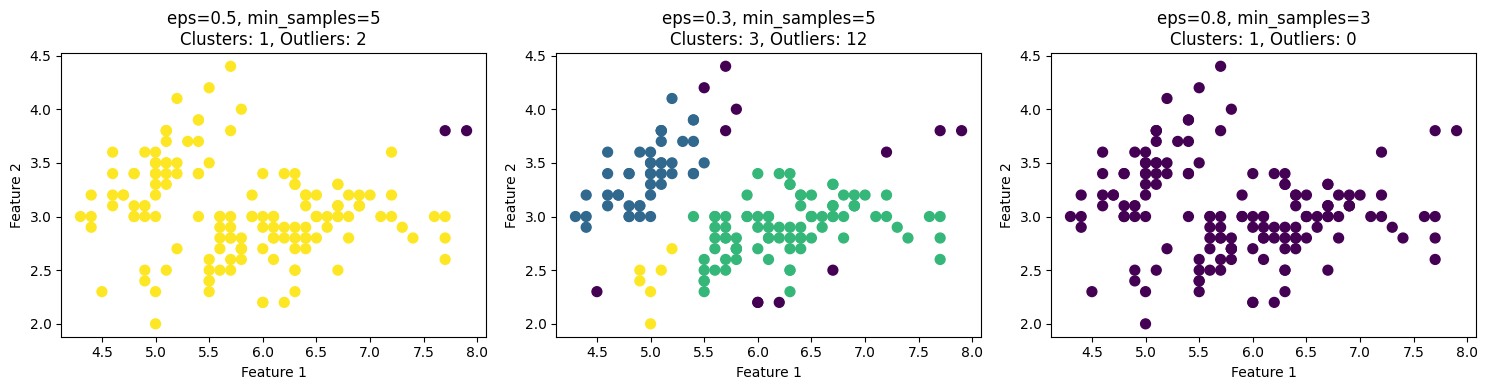

In [4]:
from sklearn.cluster import DBSCAN

params = [
    {'eps': 0.5, 'min_samples': 5},
    {'eps': 0.3, 'min_samples': 5},
    {'eps': 0.8, 'min_samples': 3},
]

fig, axes = plt.subplots(1, len(params), figsize=(5 * len(params), 4))

for i, p in enumerate(params):
    dbscan = DBSCAN(eps=p['eps'], min_samples=p['min_samples'])
    dbscan_labels = dbscan.fit_predict(X)
    
    n_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
    n_outliers = list(dbscan_labels).count(-1)
    
    axes[i].scatter(X[:, 0], X[:, 1], c=dbscan_labels, cmap='viridis', s=50)
    axes[i].set_title(f"eps={p['eps']}, min_samples={p['min_samples']}\nClusters: {n_clusters}, Outliers: {n_outliers}")
    axes[i].set_xlabel('Feature 1')
    axes[i].set_ylabel('Feature 2')

plt.tight_layout()
plt.show()

> DBSCAN identifies clusters based on density and marks points in low-density regions as outliers. The `eps` parameter defines the neighborhood radius, while `min_samples` sets the minimum points required to form a dense region. With smaller `eps`, the algorithm finds more clusters but also marks more points as outliers since fewer points fall within each neighborhood. Larger `eps` creates fewer, larger clusters and reduces outliers by grouping more distant points together. Unlike K-Means, DBSCAN does not require specifying the number of clusters in advance and can identify arbitrarily shaped clusters.

# Discussion Questions:

**1. What differences did you observe when changing the parameters for K-Means and DBSCAN?**

For K-Means, changing the random seed (initialization) can affect which points get assigned to which cluster, particularly for points near cluster boundaries. However, with well-separated clusters and k-means++ initialization, the final clustering tends to be stable. The main parameter `k` directly controls the number of clusters.

For DBSCAN, the parameters have more dramatic effects. Decreasing `eps` results in more clusters and more outliers because points need to be closer to be considered neighbors. Increasing `eps` merges clusters together and reduces outliers. Adjusting `min_samples` affects sensitivity—higher values require denser regions to form clusters, leading to more outliers.

**2. How does PCA simplify data while retaining key patterns?**

PCA simplifies high-dimensional data by projecting it onto a lower-dimensional space defined by principal components—directions of maximum variance in the data. It computes eigenvectors of the covariance matrix, ordering them by their eigenvalues (variance explained). By keeping only the top principal components, PCA reduces dimensionality while retaining the most significant patterns.

**3. Why are distance metrics crucial in these algorithms, and how would results change with different metrics?**

Distance metrics are fundamental to clustering algorithms because they define how similarity/dissimilarity between points is measured. K-Means uses standard Euclidean distance by default to assign points to the nearest centroid and calculate centroids. DBSCAN uses distance as more of a stepping stone to density, which is what is used to determine which points fall within the `eps` neighborhood.

Using different metrics for different calculations of distance would change results significantly:
- **Manhattan distance** would create diamond-shaped neighborhoods rather than circular, affecting cluster shapes
- **Cosine similarity** would focus on direction rather than magnitude, useful for text/document clustering
- **Mahalanobis distance** accounts for feature correlations and scales, potentially improving clustering on correlated data